# Mobile internet speed by country, March 2026

**Question:** Where in the world is mobile internet fastest, and how does it compare with fixed broadband in the same country?

This notebook reads the figures collected from the Ookla Speedtest Global Index for March 2026, repeats the checks in `scripts/build_data.py`, recomputes the headline figures and asserts that they match the processed tables.

## 1. Load the raw readings

One row per country, network and source.

In [1]:
import pandas as pd

raw = pd.read_csv('../data/raw/speedtest_readings_march_2026.csv', dtype={'index_month': str})
print(raw.shape)
raw.head(6)

(157, 9)


,country,region,gcc_member,network,median_download_mbps,published_rank,index_month,source,url
0,United Arab Emirates,Middle East and North Africa,yes,mobile,644.66,1.0,2026-03,Wikipedia table of Ookla Speedtest Global Index,https://en.wikipedia.org/wiki/List_of_countries_by_Internet_connection_speeds
1,United Arab Emirates,Middle East and North Africa,yes,fixed,384.51,NaN,2026-03,Wikipedia table of Ookla Speedtest Global Index,https://en.wikipedia.org/wiki/List_of_countries_by_Internet_connection_speeds
2,Qatar,Middle East and North Africa,yes,mobile,576.06,2.0,2026-03,Wikipedia table of Ookla Speedtest Global Index,https://en.wikipedia.org/wiki/List_of_countries_by_Internet_connection_speeds
3,Qatar,Middle East and North Africa,yes,fixed,211.97,NaN,2026-03,Wikipedia table of Ookla Speedtest Global Index,https://en.wikipedia.org/wiki/List_of_countries_by_Internet_connection_speeds
4,Kuwait,Middle East and North Africa,yes,mobile,372.76,3.0,2026-03,Wikipedia table of Ookla Speedtest Global Index,https://en.wikipedia.org/wiki/List_of_countries_by_Internet_connection_speeds
5,Kuwait,Middle East and North Africa,yes,fixed,230.24,NaN,2026-03,Wikipedia table of Ookla Speedtest Global Index,https://en.wikipedia.org/wiki/List_of_countries_by_Internet_connection_speeds


## 2. Data checks

In [2]:
print('rows:', len(raw), '| countries:', raw.country.nunique(), '| index months:', list(raw.index_month.unique()))
print('missing values outside published_rank:', int(raw.drop(columns='published_rank').isna().sum().sum()))
print('duplicate country/network/source:', int(raw.duplicated(['country', 'network', 'source']).sum()))
print(raw.groupby('network').median_download_mbps.agg(['min', 'max', 'count']))
raw.groupby('region').country.nunique().to_frame('countries')

rows: 157 | countries: 75 | index months: ['2026-03']
missing values outside published_rank: 0
duplicate country/network/source: 0
           min     max  count
network                      
fixed    11.65  425.46     78
mobile   22.89  644.66     79


,countries
region,
Americas,8
Asia-Pacific,18
Europe,29
Middle East and North Africa,17
Sub-Saharan Africa,3


In [3]:
spread = raw.groupby(['country', 'network']).median_download_mbps.agg(['min', 'max', 'count'])
print('figures with a second source:', int((spread['count'] > 1).sum()))
print('figures where sources disagree:', int((spread['min'] != spread['max']).sum()))
assert (spread['min'] == spread['max']).all()

figures with a second source: 7
figures where sources disagree: 0


The published ranks give a second check. If any speed in the top 40 had been misread, the ranks would no longer follow the order of the speeds.

In [4]:
mob = raw[(raw.network == 'mobile') & raw.source.str.startswith('Wikipedia')].sort_values('median_download_mbps', ascending=False).reset_index(drop=True)
ranked = mob[mob.published_rank.notna()]
assert list(ranked.published_rank.astype(int)) == list(range(1, 41))
assert (mob[mob.published_rank.isna()].median_download_mbps < ranked.median_download_mbps.min()).all()
print('ranks 1 to 40 follow the speed order; no unranked country is faster than rank 40 at', ranked.median_download_mbps.min(), 'Mbps')

ranks 1 to 40 follow the speed order; no unranked country is faster than rank 40 at 122.18 Mbps


## 3. Load the processed table

In [5]:
speed = pd.read_csv('../data/processed/speed_by_country.csv')
print(speed.shape)
speed.head(10)

(75, 12)


,country,region,gcc_member,index_month,mobile_rank_published,mobile_mbps,fixed_mbps,mobile_to_fixed_ratio,faster_network,uae_mobile_multiple,mobile_verification,fixed_verification
0,United Arab Emirates,Middle East and North Africa,yes,2026-03,1.0,644.66,384.51,1.68,mobile,1.0,two-sources,two-sources
1,Qatar,Middle East and North Africa,yes,2026-03,2.0,576.06,211.97,2.72,mobile,1.1,two-sources,single-source
2,Kuwait,Middle East and North Africa,yes,2026-03,3.0,372.76,230.24,1.62,mobile,1.7,two-sources,single-source
3,Bahrain,Middle East and North Africa,yes,2026-03,4.0,274.94,145.88,1.88,mobile,2.3,single-source,single-source
4,Brazil,Americas,no,2026-03,5.0,265.79,221.53,1.20,mobile,2.4,single-source,single-source
5,South Korea,Asia-Pacific,no,2026-03,6.0,265.20,257.76,1.03,mobile,2.4,two-sources,single-source
6,Brunei,Asia-Pacific,no,2026-03,7.0,253.69,90.29,2.81,mobile,2.5,single-source,single-source
7,Saudi Arabia,Middle East and North Africa,yes,2026-03,8.0,226.53,167.93,1.35,mobile,2.8,single-source,single-source
8,Bulgaria,Europe,no,2026-03,9.0,221.03,94.44,2.34,mobile,2.9,single-source,single-source
9,United States,Americas,no,2026-03,10.0,213.29,309.80,0.69,fixed,3.0,single-source,single-source


## 4. Finding 1: the Gulf states in the world ranking

In [6]:
top20 = speed[speed.mobile_rank_published <= 20]
gcc = speed[speed.gcc_member == 'yes']
print('GCC states in the top 20:', int((top20.gcc_member == 'yes').sum()), 'of', len(gcc))
print('GCC ranks:', {c: int(r) for c, r in zip(gcc.country, gcc.mobile_rank_published)})
assert (top20.gcc_member == 'yes').sum() == 6
assert [int(r) for r in gcc.sort_values('mobile_rank_published').mobile_rank_published] == [1, 2, 3, 4, 8, 18]
top20.groupby('region').country.count().sort_values(ascending=False).to_frame('countries_in_top_20')

GCC states in the top 20: 6 of 6
GCC ranks: {'United Arab Emirates': 1, 'Qatar': 2, 'Kuwait': 3, 'Bahrain': 4, 'Saudi Arabia': 8, 'Oman': 18}


,countries_in_top_20
region,
Europe,7
Middle East and North Africa,6
Asia-Pacific,5
Americas,2


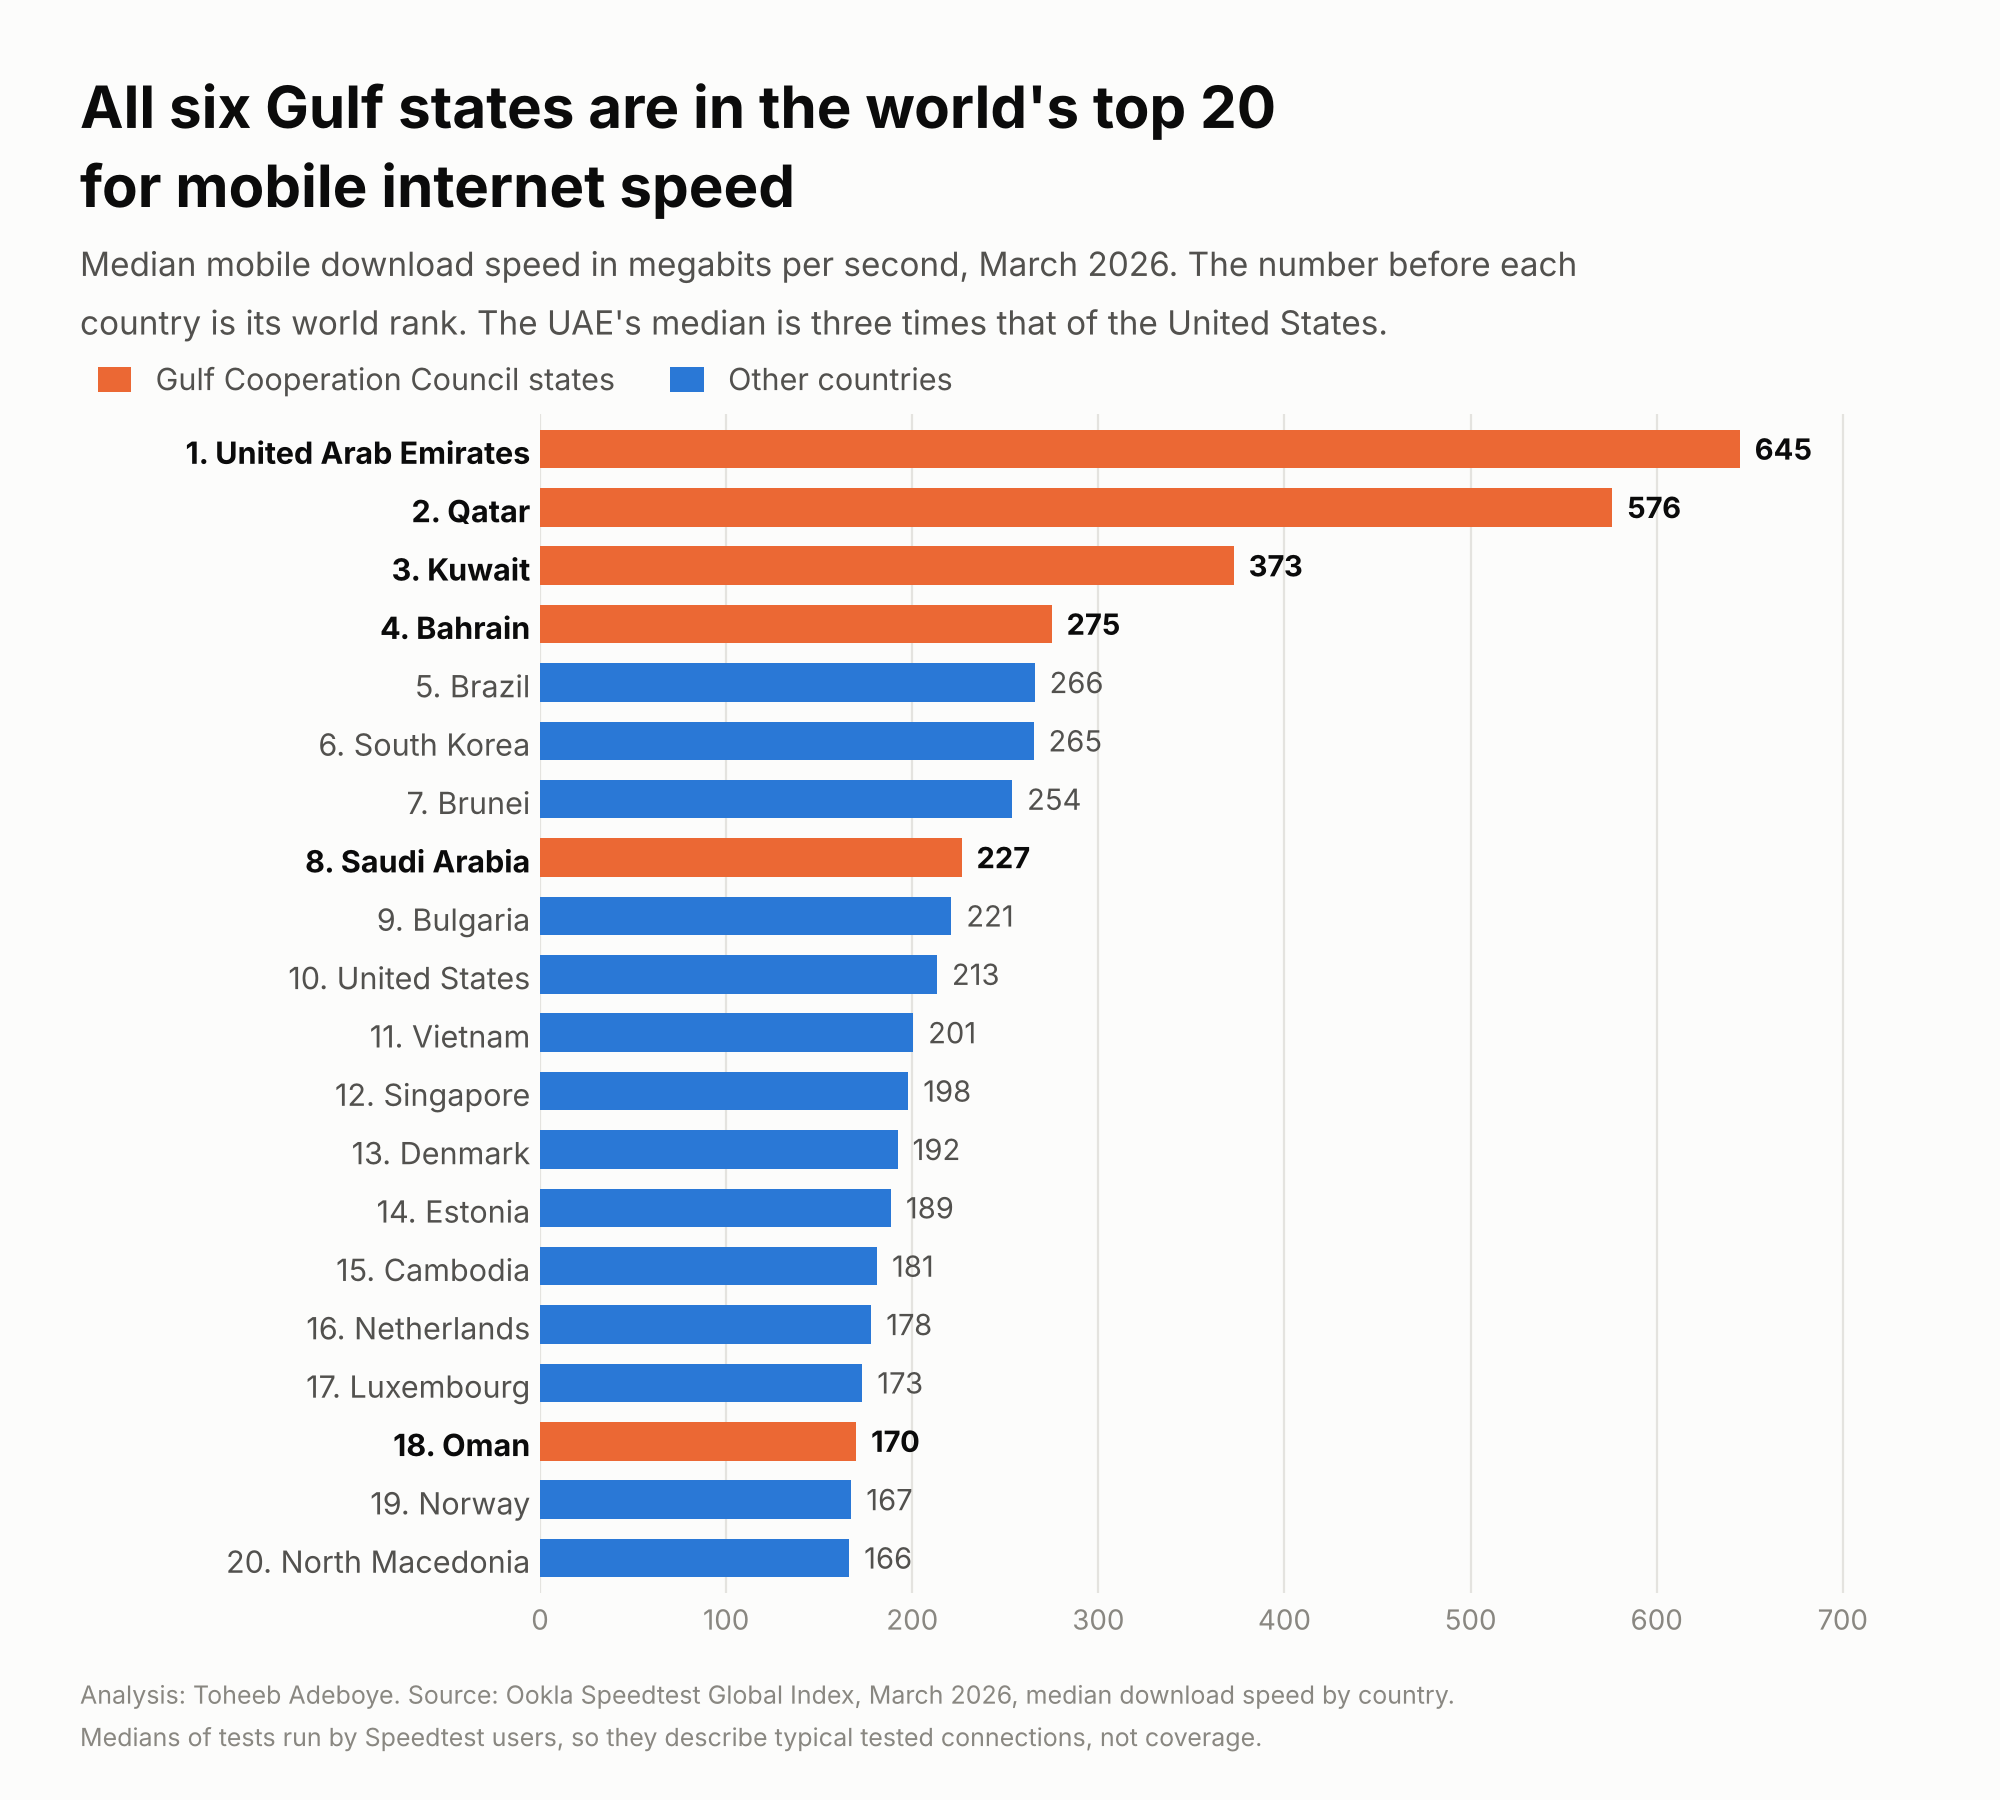

In [7]:
from IPython.display import Image
Image('../images/mobile-internet-speed-chart.png', width=760)

## 5. Finding 2: the size of the gap

In [8]:
m = speed.set_index('country').mobile_mbps
uae = m['United Arab Emirates']
for c in ['Qatar', 'United States', 'India', 'United Kingdom', 'Germany', 'Japan', 'Nigeria']:
    print(f'UAE {uae} Mbps is {uae / m[c]:.1f} times {c} ({m[c]} Mbps)')
assert round(uae / m['United States'], 1) == 3.0 and round(uae / m['Germany'], 1) == 8.6 and round(uae / m['Nigeria'], 1) == 12.8
built = speed.set_index('country').uae_mobile_multiple
assert built['Germany'] == 8.6 and built['Nigeria'] == 12.8

UAE 644.66 Mbps is 1.1 times Qatar (576.06 Mbps)
UAE 644.66 Mbps is 3.0 times United States (213.29 Mbps)
UAE 644.66 Mbps is 5.1 times India (126.73 Mbps)
UAE 644.66 Mbps is 8.5 times United Kingdom (75.91 Mbps)
UAE 644.66 Mbps is 8.6 times Germany (74.58 Mbps)
UAE 644.66 Mbps is 9.2 times Japan (70.28 Mbps)
UAE 644.66 Mbps is 12.8 times Nigeria (50.53 Mbps)


## 6. Finding 3: mobile against fixed broadband

In [9]:
ratio = (speed.mobile_mbps / speed.fixed_mbps).round(2)
assert (ratio == speed.mobile_to_fixed_ratio).all(), 'notebook and build script disagree'
print('countries where mobile is faster:', int((speed.faster_network == 'mobile').sum()), 'of', len(speed))
print('GCC states where mobile is faster:', int((gcc.faster_network == 'mobile').sum()), 'of', len(gcc))
assert (gcc.faster_network == 'mobile').all()
gcc[['country', 'mobile_mbps', 'fixed_mbps', 'mobile_to_fixed_ratio']]

countries where mobile is faster: 33 of 75
GCC states where mobile is faster: 6 of 6


,country,mobile_mbps,fixed_mbps,mobile_to_fixed_ratio
0,United Arab Emirates,644.66,384.51,1.68
1,Qatar,576.06,211.97,2.72
2,Kuwait,372.76,230.24,1.62
3,Bahrain,274.94,145.88,1.88
7,Saudi Arabia,226.53,167.93,1.35
17,Oman,169.87,96.05,1.77


In [10]:
names = ['Japan', 'France', 'United Kingdom', 'Singapore', 'United States', 'Germany', 'South Korea', 'Nigeria', 'India']
speed.set_index('country').loc[names, ['mobile_mbps', 'fixed_mbps', 'mobile_to_fixed_ratio', 'faster_network']]

,mobile_mbps,fixed_mbps,mobile_to_fixed_ratio,faster_network
country,,,,
Japan,70.28,255.27,0.28,fixed
France,152.50,352.35,0.43,fixed
United Kingdom,75.91,172.24,0.44,fixed
Singapore,197.89,425.46,0.47,fixed
United States,213.29,309.80,0.69,fixed
Germany,74.58,103.72,0.72,fixed
South Korea,265.20,257.76,1.03,mobile
Nigeria,50.53,36.81,1.37,mobile
India,126.73,60.85,2.08,mobile


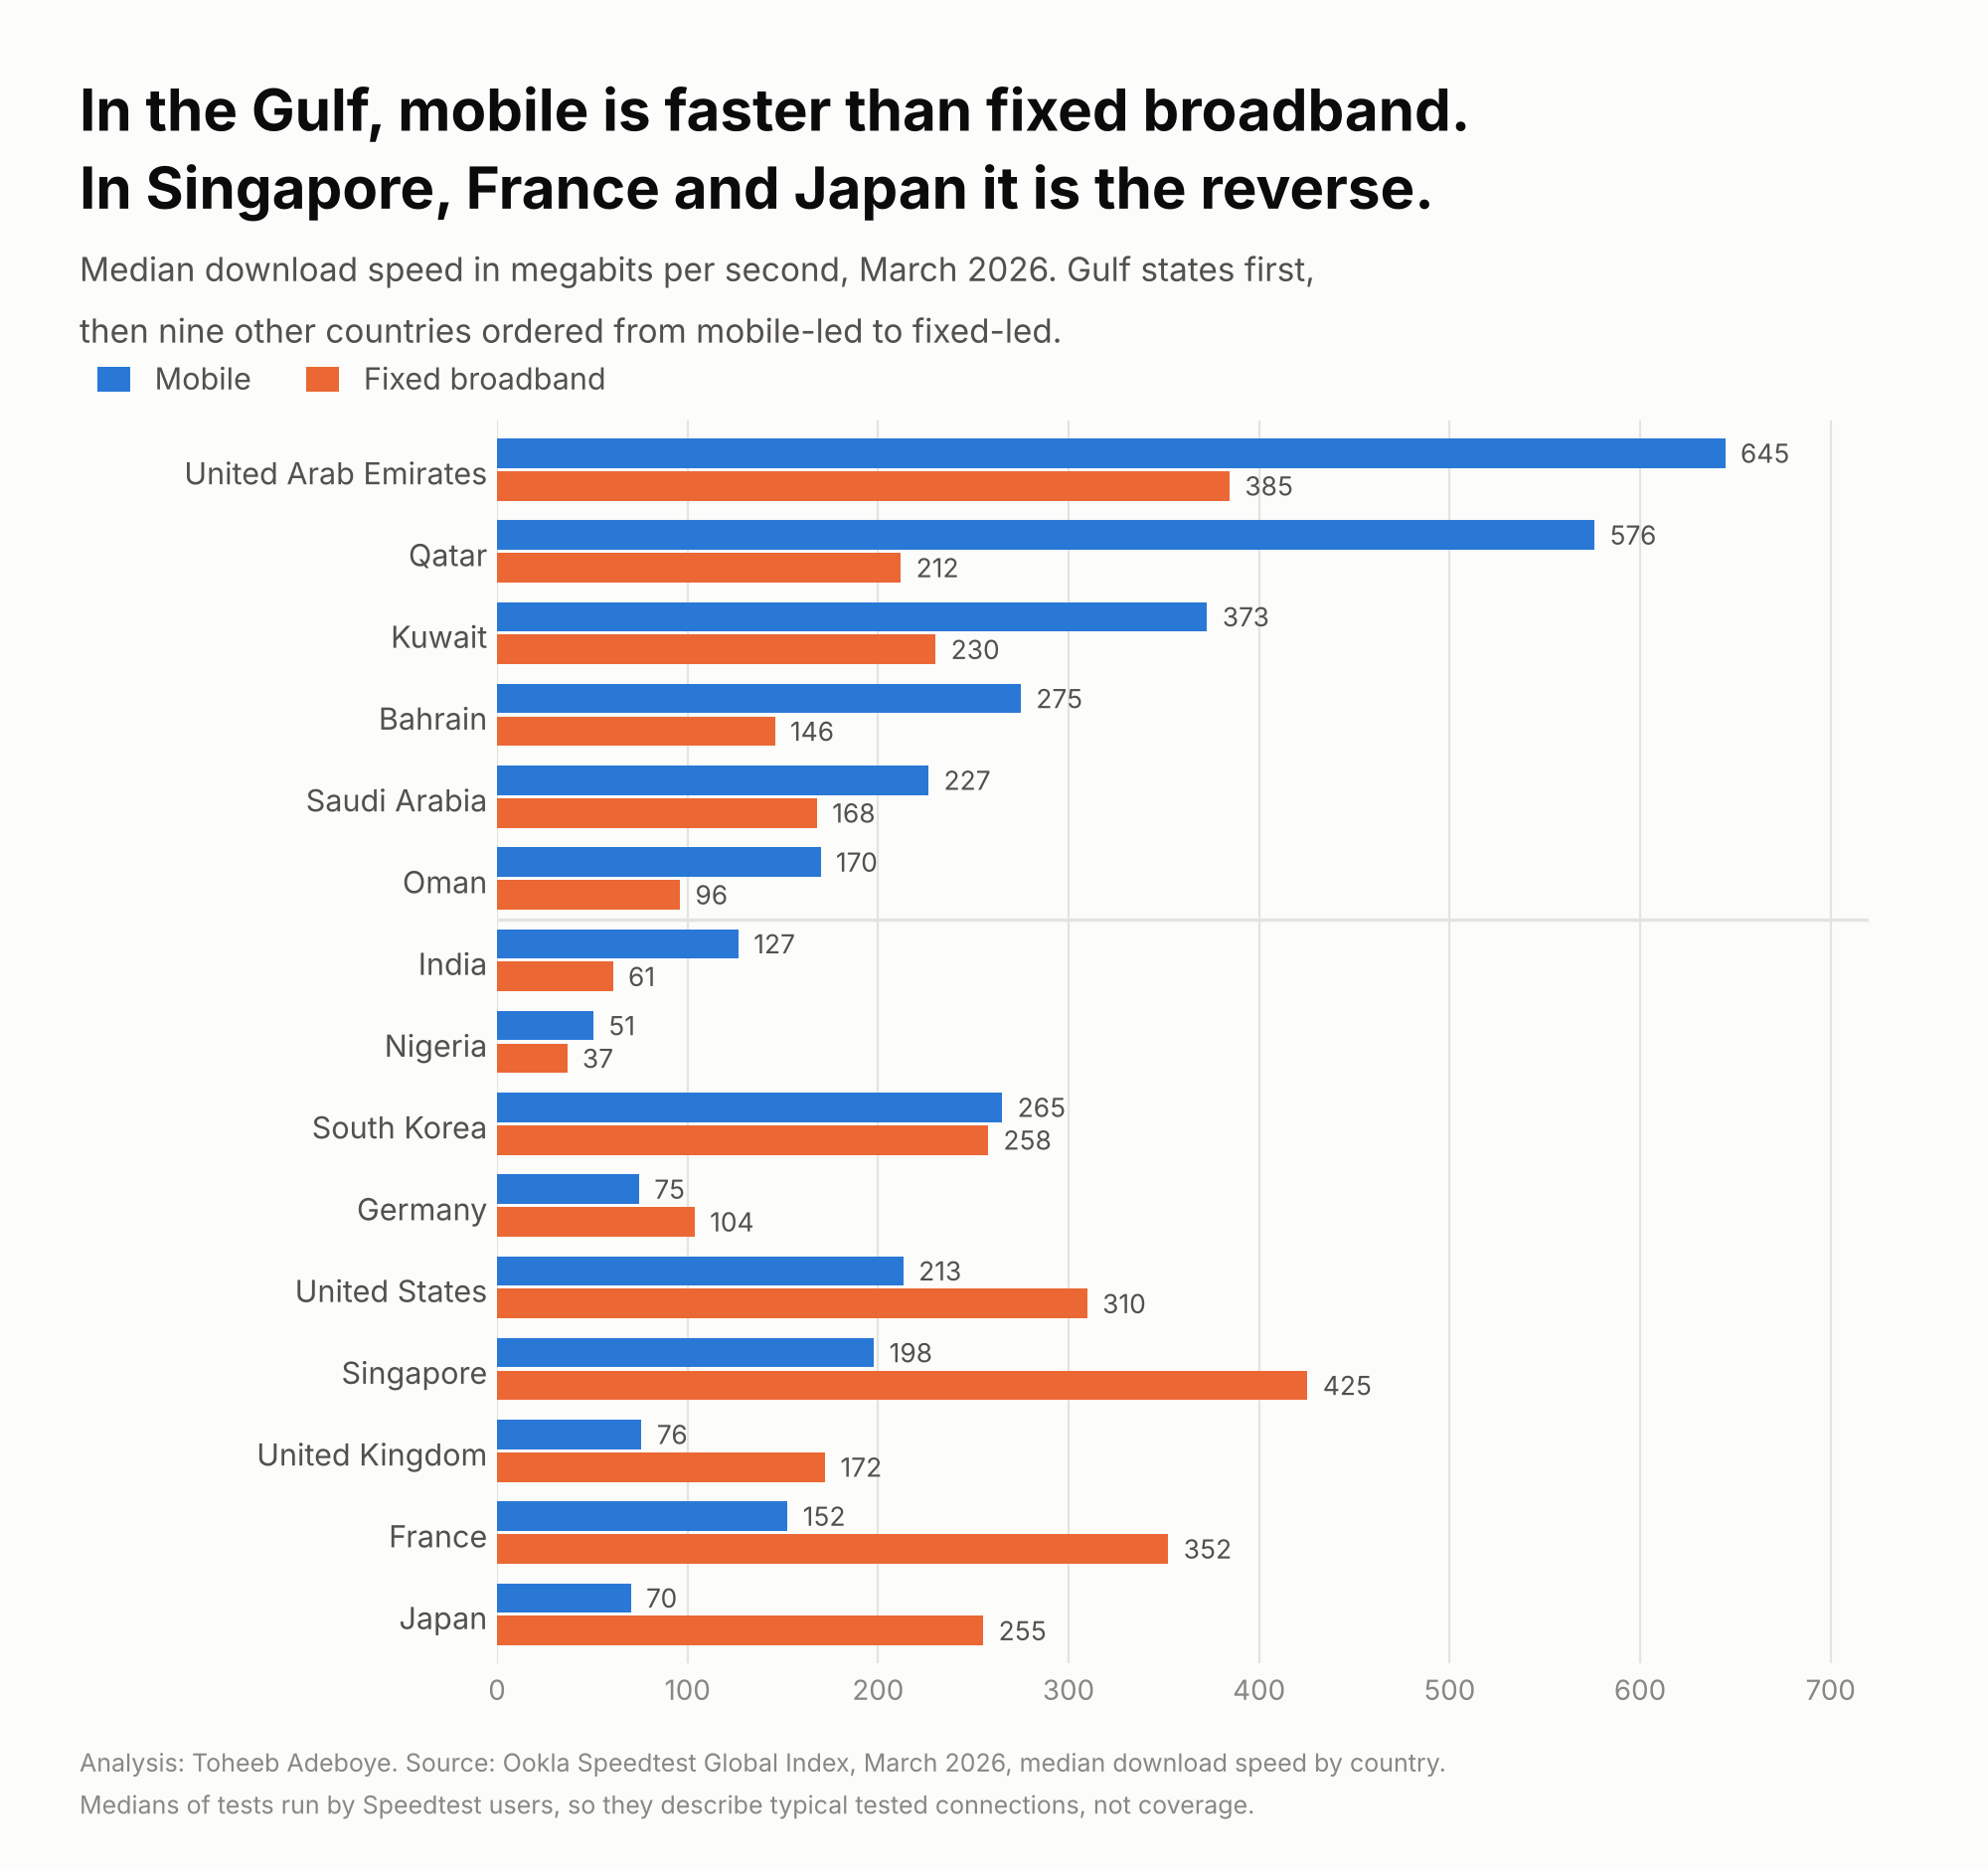

In [11]:
Image('../images/mobile_vs_fixed.png', width=760)

## 7. Middle East and North Africa, then the other regions

The countries collected are the full top 40 for mobile plus 35 others chosen to cover every region. They are not the whole index, so the group medians below describe this sample only.

In [12]:
mena = speed[speed.region == 'Middle East and North Africa'][['country', 'mobile_mbps', 'fixed_mbps', 'faster_network']]
mena

,country,mobile_mbps,fixed_mbps,faster_network
0,United Arab Emirates,644.66,384.51,mobile
1,Qatar,576.06,211.97,mobile
2,Kuwait,372.76,230.24,mobile
3,Bahrain,274.94,145.88,mobile
7,Saudi Arabia,226.53,167.93,mobile
17,Oman,169.87,96.05,mobile
43,Turkey,110.40,80.02,mobile
51,Morocco,77.54,56.22,mobile
56,Israel,65.96,281.29,fixed
57,Iraq,64.74,44.19,mobile


In [13]:
groups = pd.read_csv('../data/processed/group_summary.csv')
mine = round(gcc.mobile_mbps.median(), 2)
assert mine == groups.set_index('group').loc['GCC states', 'median_mobile_mbps']
groups

,group,countries,median_mobile_mbps,median_fixed_mbps,min_mobile_mbps,max_mobile_mbps,countries_mobile_faster
0,GCC states,6,323.85,189.95,169.87,644.66,6
1,Americas (countries collected),8,72.42,239.95,40.02,265.79,1
2,Asia-Pacific (countries collected),18,124.46,184.99,26.46,265.20,6
3,Europe (countries collected),29,145.54,180.47,74.58,221.03,9
4,Middle East and North Africa (countries collected),17,65.96,92.50,22.89,644.66,14
5,Sub-Saharan Africa (countries collected),3,50.53,36.81,48.78,68.09,3
6,All countries collected,75,124.08,168.07,22.89,644.66,33


## 8. Other months

Readings for other months of the same index, collected from secondary sources, show the direction over time. Each of these rests on one source unless two rows are shown for the same month.

In [14]:
other = pd.read_csv('../data/raw/speedtest_other_months.csv', dtype={'index_month': str})
other[other.country.isin(['United Arab Emirates', 'Qatar'])].sort_values(['country', 'index_month'])[['country', 'index_month', 'median_download_mbps', 'source']]

,country,index_month,median_download_mbps,source
1,Qatar,2023-12,244.44,Databoks (Katadata)
8,Qatar,2025-10,515.00,Cellesim mobile internet speeds by country 2026
14,Qatar,2026-09,535.94,Statista
0,United Arab Emirates,2023-12,303.21,Databoks (Katadata)
6,United Arab Emirates,2025-10,652.87,Earthsims country connectivity speeds
7,United Arab Emirates,2025-10,653.00,Cellesim mobile internet speeds by country 2026
13,United Arab Emirates,2026-09,675.51,Statista


## 9. Summary

- All six Gulf Cooperation Council states are in the world top 20 for median mobile download speed in March 2026, and four of them hold the first four places.
- The UAE median, 644.66 Mbps, is 3.0 times the United States, 8.6 times Germany and 12.8 times Nigeria.
- Mobile is faster than fixed broadband in all six Gulf states. In Singapore, France, the United Kingdom and Japan fixed broadband is more than twice as fast as mobile.
- Seven figures are confirmed in a second source. The rest come from one transcription of the index, tested with the rank-order check.